In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcbG9pY2hcRG9jdW1lbnRzXFdvcmtcR2l0aHViXHF1YXJ0b1xweXRob25faWFfcXVhcnRvXG1vZHVsZXNcbW9kdWxlXzA0'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python

In [2]:
#| label: setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
np.random.seed(42)

print("✅ Environnement prêt")

✅ Environnement prêt


In [3]:
# Exemple : prédire le prix d'un appartement
# y peut être 150_000, 234_500.75, 1_200_000, etc.

In [4]:
#| eval: false
# TODO: Exercice 1 — tes réponses en commentaire ou markdown

C:\Users\loich\AppData\Local\Temp\ipykernel_33376\3188994502.py:49: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\loich\AppData\Local\Temp\ipykernel_33376\3188994502.py:49: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\loich\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\loich\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


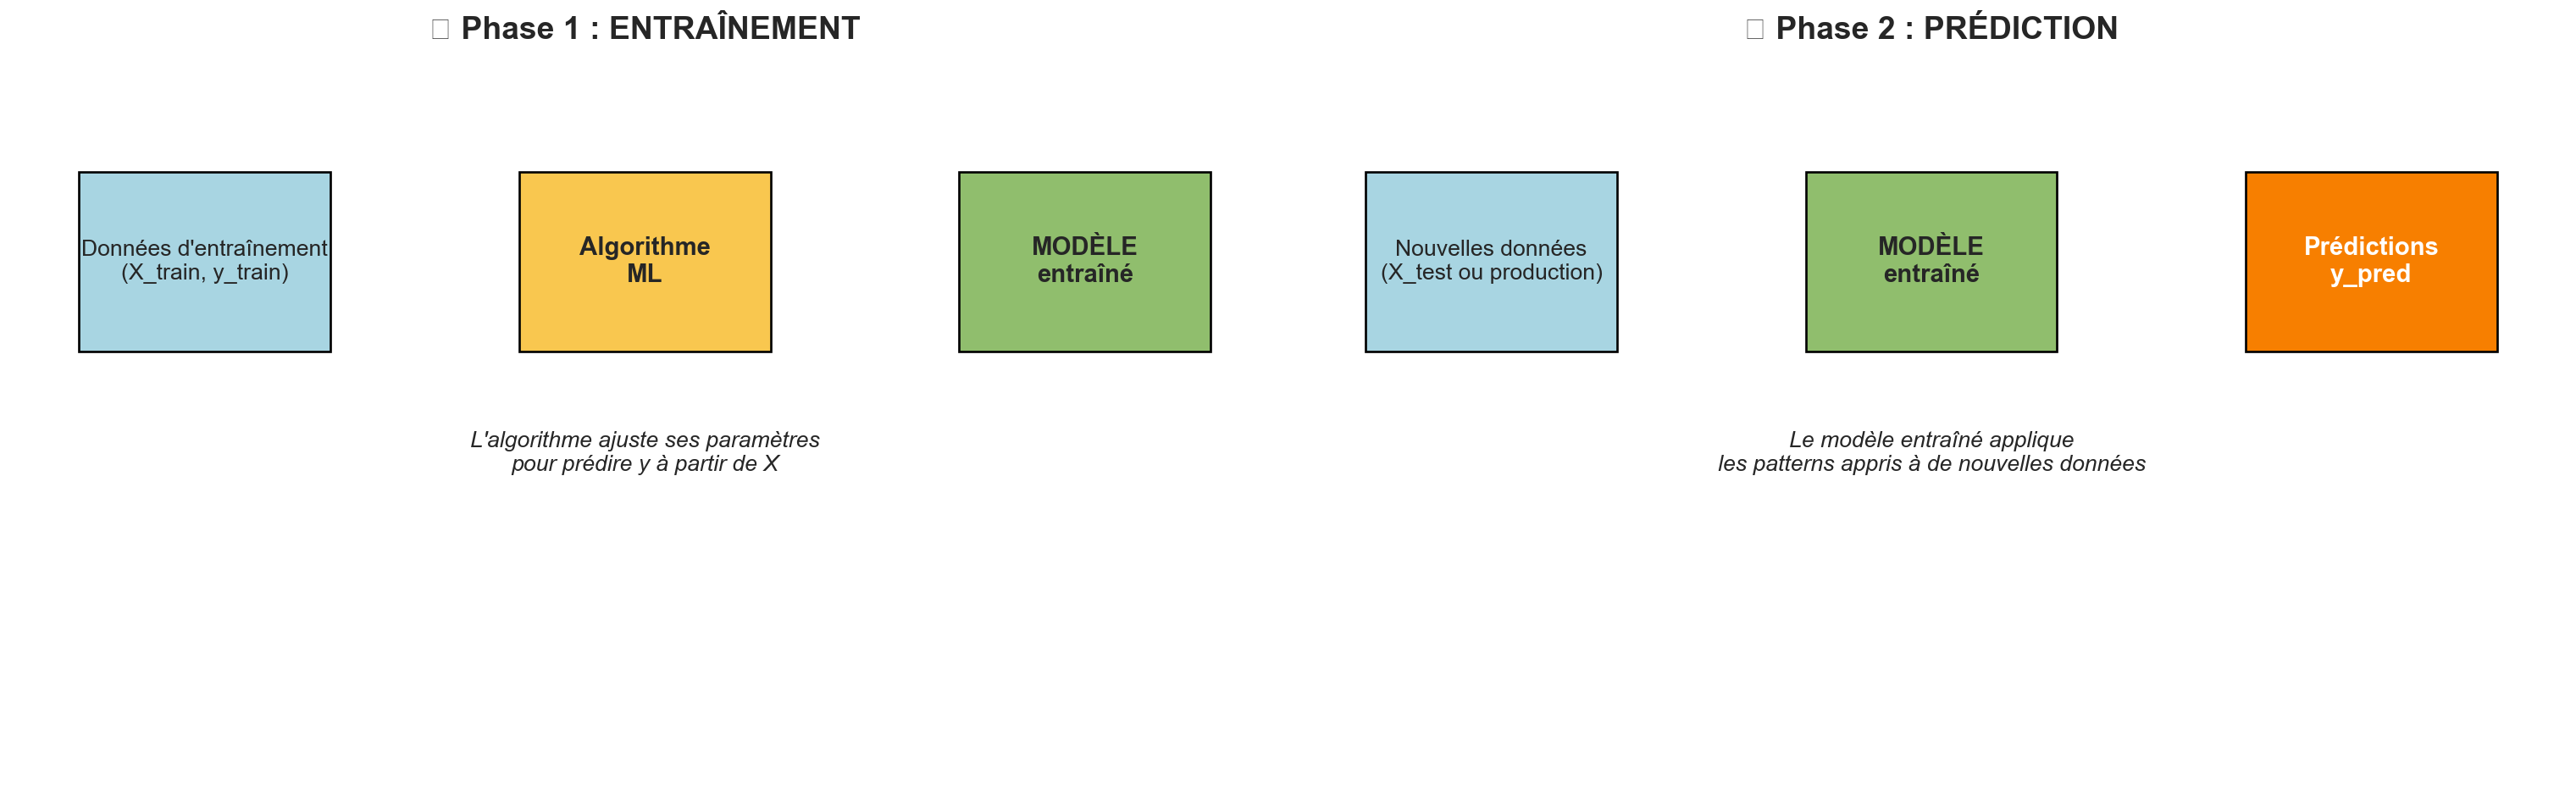

In [5]:
#| label: fig-workflow
#| fig-cap: 'Le workflow général : entraînement (gauche) et prédiction (droite)'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# === Entraînement ===
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis("off")
ax.set_title("🎓 Phase 1 : ENTRAÎNEMENT", fontsize=14, fontweight="bold")

# Boîtes
ax.add_patch(plt.Rectangle((0.5, 3.5), 2, 1.5, facecolor="#a8d5e2", edgecolor="black"))
ax.text(1.5, 4.25, "Données d'entraînement\n(X_train, y_train)", ha="center", va="center", fontsize=10)

ax.add_patch(plt.Rectangle((4, 3.5), 2, 1.5, facecolor="#f9c74f", edgecolor="black"))
ax.text(5, 4.25, "Algorithme\nML", ha="center", va="center", fontsize=11, fontweight="bold")

ax.add_patch(plt.Rectangle((7.5, 3.5), 2, 1.5, facecolor="#90be6d", edgecolor="black"))
ax.text(8.5, 4.25, "MODÈLE\nentraîné", ha="center", va="center", fontsize=11, fontweight="bold")

# Flèches
ax.annotate("", xy=(4, 4.25), xytext=(2.5, 4.25), arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("", xy=(7.5, 4.25), xytext=(6, 4.25), arrowprops=dict(arrowstyle="->", lw=2))

ax.text(5, 2.5, "L'algorithme ajuste ses paramètres\npour prédire y à partir de X",
        ha="center", style="italic", fontsize=10)

# === Prédiction ===
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis("off")
ax.set_title("🔮 Phase 2 : PRÉDICTION", fontsize=14, fontweight="bold")

ax.add_patch(plt.Rectangle((0.5, 3.5), 2, 1.5, facecolor="#a8d5e2", edgecolor="black"))
ax.text(1.5, 4.25, "Nouvelles données\n(X_test ou production)", ha="center", va="center", fontsize=10)

ax.add_patch(plt.Rectangle((4, 3.5), 2, 1.5, facecolor="#90be6d", edgecolor="black"))
ax.text(5, 4.25, "MODÈLE\nentraîné", ha="center", va="center", fontsize=11, fontweight="bold")

ax.add_patch(plt.Rectangle((7.5, 3.5), 2, 1.5, facecolor="#f77f00", edgecolor="black"))
ax.text(8.5, 4.25, "Prédictions\ny_pred", ha="center", va="center", fontsize=11, fontweight="bold", color="white")

ax.annotate("", xy=(4, 4.25), xytext=(2.5, 4.25), arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("", xy=(7.5, 4.25), xytext=(6, 4.25), arrowprops=dict(arrowstyle="->", lw=2))

ax.text(5, 2.5, "Le modèle entraîné applique\nles patterns appris à de nouvelles données",
        ha="center", style="italic", fontsize=10)

plt.tight_layout()
plt.show()

In [6]:
# Exemple : dataset immobilier
exemple = pd.DataFrame({
    "surface": [50, 75, 100],
    "nb_pieces": [2, 3, 4],
    "prix": [200_000, 300_000, 450_000]
})
print(exemple)

   surface  nb_pieces    prix
0       50          2  200000
1       75          3  300000
2      100          4  450000


C:\Users\loich\AppData\Local\Temp\ipykernel_33376\1910590097.py:30: RankWarning: Polyfit may be poorly conditioned
  p20 = np.polyfit(x, y_observe, 20)


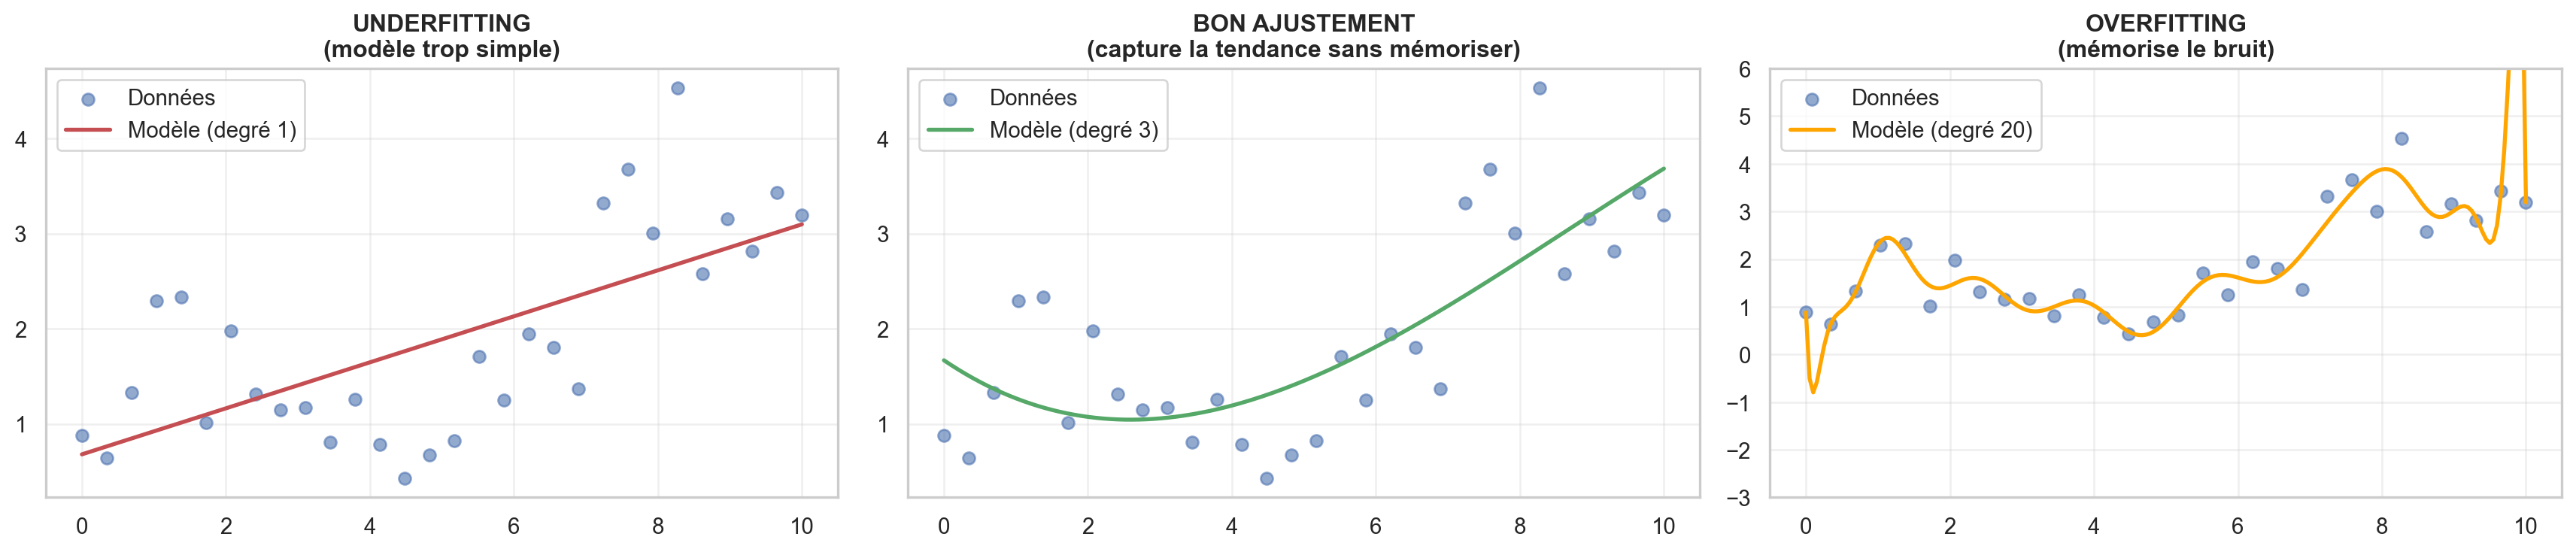

In [7]:
#| label: fig-overfitting
#| fig-cap: Illustration visuelle d'underfitting, bon ajustement, overfitting

np.random.seed(0)

# Générer des données
x = np.linspace(0, 10, 30)
y_vrai = np.sin(x) + 0.3*x
y_observe = y_vrai + np.random.normal(0, 0.5, 30)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Points de test pour tracer les prédictions
x_test = np.linspace(0, 10, 200)

# Underfitting : degré 1 (droite)
p1 = np.polyfit(x, y_observe, 1)
axes[0].scatter(x, y_observe, alpha=0.6, label="Données")
axes[0].plot(x_test, np.polyval(p1, x_test), "r-", lw=2, label="Modèle (degré 1)")
axes[0].set_title("UNDERFITTING\n(modèle trop simple)", fontsize=12, fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bon équilibre : degré 3
p3 = np.polyfit(x, y_observe, 3)
axes[1].scatter(x, y_observe, alpha=0.6, label="Données")
axes[1].plot(x_test, np.polyval(p3, x_test), "g-", lw=2, label="Modèle (degré 3)")
axes[1].set_title("BON AJUSTEMENT\n(capture la tendance sans mémoriser)", fontsize=12, fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Overfitting : degré 20
p20 = np.polyfit(x, y_observe, 20)
axes[2].scatter(x, y_observe, alpha=0.6, label="Données")
axes[2].plot(x_test, np.polyval(p20, x_test), "orange", lw=2, label="Modèle (degré 20)")
axes[2].set_title("OVERFITTING\n(mémorise le bruit)", fontsize=12, fontweight="bold")
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(-3, 6)

plt.tight_layout()
plt.show()

In [8]:
#| eval: false
# TODO: Exercice 2

In [9]:
# Générons un problème de régression simple : prédire le prix d'un appartement
np.random.seed(42)
n = 200

data = pd.DataFrame({
    "surface": np.random.uniform(30, 150, n),
    "nb_pieces": np.random.randint(1, 6, n),
    "etage": np.random.randint(0, 10, n)
})

# Vraie relation (que notre modèle va essayer d'apprendre)
data["prix"] = (
    2500 * data["surface"]
    + 15000 * data["nb_pieces"]
    + 3000 * data["etage"]
    + np.random.normal(0, 20000, n)  # bruit
).round().astype(int)

print(data.head())

      surface  nb_pieces  etage    prix
0   74.944814          4      0  215473
1  144.085717          3      7  414227
2  117.839273          1      9  336703
3  101.839018          4      1  318537
4   48.722237          4      2  178804


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Séparer X et y
X = data[["surface", "nb_pieces", "etage"]]
y = data["prix"]

# 2. Train / test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Créer et entraîner le modèle
modele = LinearRegression()
modele.fit(X_train, y_train)

# 4. Prédire sur le test
y_pred = modele.predict(X_test)

# 5. Évaluer
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² sur test : {r2:.3f}")
print(f"MAE sur test : {mae:,.0f} €")

R² sur test : 0.949
MAE sur test : 16,405 €


In [11]:
# Les coefficients appris
for feature, coef in zip(X.columns, modele.coef_):
    print(f"  {feature:12s} : {coef:,.2f} €")
print(f"  {'intercept':12s} : {modele.intercept_:,.2f} €")

  surface      : 2,605.84 €
  nb_pieces    : 15,308.18 €
  etage        : 2,653.81 €
  intercept    : -11,577.59 €


In [12]:
# Score sur train VS test
r2_train = modele.score(X_train, y_train)
r2_test = modele.score(X_test, y_test)

print(f"R² sur train : {r2_train:.4f}")
print(f"R² sur test  : {r2_test:.4f}")
print(f"Gap          : {r2_train - r2_test:.4f}")

R² sur train : 0.9576
R² sur test  : 0.9488
Gap          : 0.0088


In [13]:
#| eval: false
# TODO: Exercice 3

In [14]:
from sklearn.linear_model import LogisticRegression

# Recréer le dataset
np.random.seed(0)
n = 500
etudiants = pd.DataFrame({
    "heures_etude": np.random.normal(10, 5, n).clip(0, 30),
    "nb_absences": np.random.poisson(5, n),
    "moyenne_precedente": np.random.normal(12, 3, n).clip(0, 20),
})
score = (
    0.3 * etudiants["heures_etude"]
    - 0.2 * etudiants["nb_absences"]
    + 0.5 * etudiants["moyenne_precedente"]
    + np.random.normal(0, 1, n)
)
etudiants["obtient_diplome"] = (score > score.median()).astype(int)

# 1. X et y
X = etudiants.drop(columns="obtient_diplome")
y = etudiants["obtient_diplome"]

# 2. Split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3 & 4. Modèle + entraînement
modele = LogisticRegression(max_iter=1000)
modele.fit(X_train, y_train)

# 5 & 6. Scores
acc_train = modele.score(X_train, y_train)
acc_test = modele.score(X_test, y_test)

print(f"Accuracy train : {acc_train:.3f}")
print(f"Accuracy test  : {acc_test:.3f}")
print(f"Gap            : {acc_train - acc_test:.3f}")

Accuracy train : 0.865
Accuracy test  : 0.890
Gap            : -0.025


In [15]:
# Exemple : baseline en régression
# On reprend ici le dataset appartements du début de la notion pour une démonstration autonome
np.random.seed(42)
n = 200
data_demo = pd.DataFrame({
    "surface": np.random.normal(60, 20, n).clip(20, 150),
    "nb_pieces": np.random.randint(1, 6, n),
    "etage": np.random.randint(0, 10, n)
})
data_demo["prix"] = (
    2500 * data_demo["surface"] + 15000 * data_demo["nb_pieces"]
    + 3000 * data_demo["etage"] + np.random.normal(0, 20000, n)
).round().astype(int)

X_demo = data_demo[["surface", "nb_pieces", "etage"]]
y_demo = data_demo["prix"]
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(X_demo, y_demo, test_size=0.2, random_state=42)

modele_demo = LinearRegression()
modele_demo.fit(X_tr_d, y_tr_d)
y_pred_demo = modele_demo.predict(X_te_d)

# Baseline : prédire toujours la moyenne de y_train
baseline_pred = np.full_like(y_te_d, y_tr_d.mean(), dtype=float)
mae_baseline = mean_absolute_error(y_te_d, baseline_pred)
mae_modele = mean_absolute_error(y_te_d, y_pred_demo)

print(f"MAE baseline (moyenne) : {mae_baseline:,.0f} €")
print(f"MAE notre modèle       : {mae_modele:,.0f} €")
print(f"Réduction d'erreur     : {(1 - mae_modele / mae_baseline) * 100:.1f}%")

MAE baseline (moyenne) : 45,528 €
MAE notre modèle       : 22,244 €
Réduction d'erreur     : 51.1%


In [16]:
#| eval: false
# TODO: Exercice bilan

In [17]:
# Créer le dataset
np.random.seed(42)
n = 800
df = pd.DataFrame({
    "age": np.random.randint(18, 65, n),
    "anciennete": np.random.exponential(5, n).clip(0, 30),
    "salaire": np.random.normal(3000, 800, n),
    "heures_supp": np.random.gamma(2, 2, n),
})
proba = (
    0.1 
    + 0.15 * (df["heures_supp"] > 5)
    + 0.10 * (df["anciennete"] < 2)
    - 0.05 * (df["salaire"] > 3500)
).clip(0, 1)
df["part"] = (np.random.random(n) < proba).astype(int)

In [18]:
# 1. Répartition cible
print(df["part"].value_counts(normalize=True).round(3))
print(f"Taux de départ : {df['part'].mean() * 100:.1f}%")

part
0    0.829
1    0.171
Name: proportion, dtype: float64
Taux de départ : 17.1%


In [19]:
# 2. X et y
X = df.drop(columns="part")
y = df["part"]

# 3. Split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
# 4. Baseline : classe majoritaire (toujours 0 = ne part pas)
acc_baseline = (y_test == 0).mean()
print(f"Baseline (prédire 'ne part pas') : {acc_baseline:.3f}")

Baseline (prédire 'ne part pas') : 0.831


In [21]:
# 5-6. Modèle
modele = LogisticRegression(max_iter=1000)
modele.fit(X_train, y_train)

acc_train = modele.score(X_train, y_train)
acc_test = modele.score(X_test, y_test)

print(f"Accuracy train  : {acc_train:.3f}")
print(f"Accuracy test   : {acc_test:.3f}")
print(f"Gap             : {acc_train - acc_test:+.3f}")

Accuracy train  : 0.828
Accuracy test   : 0.831
Gap             : -0.003


In [22]:
# 7. Comparaison baseline
print(f"\nBaseline : {acc_baseline:.3f}")
print(f"Modèle   : {acc_test:.3f}")
if acc_test > acc_baseline + 0.02:
    print("✅ Le modèle apporte de la valeur (bat la baseline de > 2%)")
else:
    print("⚠️  Le modèle ne bat pas (ou à peine) la baseline")


Baseline : 0.831
Modèle   : 0.831
⚠️  Le modèle ne bat pas (ou à peine) la baseline


In [23]:
# 8. Coefficients
print("\n=== Coefficients de la régression logistique ===")
for feature, coef in zip(X.columns, modele.coef_[0]):
    signe = "+" if coef > 0 else ""
    print(f"  {feature:12s} : {signe}{coef:.4f}")


=== Coefficients de la régression logistique ===
  age          : -0.0079
  anciennete   : +0.0105
  salaire      : -0.0002
  heures_supp  : +0.0610
